# 13 - Inferencia en Batch
## Predicciones masivas programadas vs. predicciones en tiempo real

**¿Qué es la inferencia en batch?**  
En lugar de predecir de a una solicitud (como hace la API del NB06),  
la inferencia en batch procesa **miles o millones de registros de una sola vez**,  
normalmente de forma programada (cada noche, cada semana).

**¿Cuándo usar batch vs. tiempo real?**

| Criterio | Tiempo Real (API) | Batch |
|----------|------------------|-------|
| Latencia requerida | Milisegundos | Minutos / horas |
| Volumen | 1 registro por vez | Miles o millones |
| Ejemplo | Precio al instante en la web | Valorar toda la cartera del banco cada noche |
| Coste | Alto (servidor siempre activo) | Bajo (corre y se apaga) |
| Complejidad | Baja | Media |

**Este notebook demuestra:**
- Cómo aplicar el mismo pipeline de transformaciones que la API (training-serving parity)
- Cómo procesar un lote de registros de forma eficiente
- Cómo guardar los resultados con trazabilidad
- Métricas de rendimiento: throughput y latencia
- Cómo se schedularía en producción (cron, Airflow)

**Este notebook genera:**
- `experiments/batch_output/predicciones_batch_<fecha>.csv`
- `experiments/batch_output/reporte_batch_<fecha>.json`

## Prerequisitos
- Haber ejecutado: `05_evaluacion_final.ipynb`
- Requiere: `experiments/modelo_produccion.pkl`, `experiments/scaler.pkl`
- Este notebook genera: `experiments/batch_output/` con resultados del batch

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

EXP_DIR   = ROOT / 'experiments'
DATA_DIR  = ROOT / 'data' / 'processed'
BATCH_DIR = EXP_DIR / 'batch_output'
BATCH_DIR.mkdir(exist_ok=True)

FECHA_HOY = datetime.now().strftime('%Y%m%d_%H%M%S')

print(f'ROOT      : {ROOT}')
print(f'BATCH_DIR : {BATCH_DIR}')
print(f'Timestamp : {FECHA_HOY}')

ROOT      : C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida
BATCH_DIR : C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\batch_output
Timestamp : 20260318_101429


## 1. Cargar el Modelo y el Scaler

El punto de partida es siempre cargar los mismos artefactos que usa la API.  
Esto garantiza **training-serving parity**: las mismas transformaciones, el mismo modelo.

In [2]:
# ── Cargar modelo ─────────────────────────────────────────────────────────
with open(EXP_DIR / 'modelo_produccion.pkl', 'rb') as f:
    modelo = pickle.load(f)

# ── Cargar scaler ─────────────────────────────────────────────────────────
with open(EXP_DIR / 'scaler.pkl', 'rb') as f:
    scaler_obj = pickle.load(f)

if isinstance(scaler_obj, dict):
    scaler          = scaler_obj['scaler']
    columnas_scaler = scaler_obj['columnas']
else:
    scaler          = scaler_obj
    columnas_scaler = None

print('Artefactos cargados:')
print(f'  Modelo  : {type(modelo).__name__}')
print(f'  Scaler  : {type(scaler).__name__}')
if columnas_scaler:
    print(f'  Columnas escaladas ({len(columnas_scaler)}): {columnas_scaler}')

Artefactos cargados:
  Modelo  : GradientBoostingRegressor
  Scaler  : StandardScaler
  Columnas escaladas (13): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'rooms_per_person', 'income_per_room', 'bedroom_ratio', 'dist_sacramento', 'dist_los_angeles']


## 2. Preparar el Lote de Datos

En producción, el batch llega desde un sistema externo:  
una base de datos, un fichero S3, un topic de Kafka, etc.

Aquí simulamos tres escenarios realistas:
- **Caso A**: datos crudos (8 features originales) — requieren feature engineering
- **Caso B**: datos ya procesados (13 features) — solo predecir
- **Caso C**: datos con algunos errores — demostrar detección de problemas

In [3]:
# ── Pipeline de feature engineering (mismo que en API y NB02) ─────────────
def crear_features(df: pd.DataFrame) -> pd.DataFrame:
    """Replica exacta del pipeline de ingeniería de features del NB02."""
    df = df.copy()
    df['rooms_per_person']  = df['AveRooms']  / (df['AveOccup']  + 1e-6)
    df['income_per_room']   = df['MedInc']    / (df['AveRooms']  + 1e-6)
    df['bedroom_ratio']     = df['AveBedrms'] / (df['AveRooms']  + 1e-6)
    df['dist_sacramento']   = np.sqrt((df['Latitude'] - 38.5)**2 + (df['Longitude'] - (-121.5))**2)
    df['dist_los_angeles']  = np.sqrt((df['Latitude'] - 34.0)**2 + (df['Longitude'] - (-118.2))**2)
    return df

FEATURES_ORIG = ['MedInc','HouseAge','AveRooms','AveBedrms',
                 'Population','AveOccup','Latitude','Longitude']
FEATURES_TODAS = FEATURES_ORIG + ['rooms_per_person','income_per_room',
                                   'bedroom_ratio','dist_sacramento','dist_los_angeles']

def preparar_batch(df_crudo: pd.DataFrame) -> pd.DataFrame:
    """
    Pipeline completo batch:
    1. Crear features derivadas
    2. Aplicar scaler (mismo que en entrenamiento)
    """
    df = crear_features(df_crudo)
    cols_a_escalar = columnas_scaler if columnas_scaler else FEATURES_TODAS
    cols_presentes = [c for c in cols_a_escalar if c in df.columns]
    df[cols_presentes] = scaler.transform(df[cols_presentes])
    return df[FEATURES_TODAS]

# ── Generar datos de entrada del batch ────────────────────────────────────
# Usamos el test set como proxy de datos de producción reales
# (en producción llegarían sin el target MedHouseVal)
raw_df = pd.read_csv(ROOT / 'data' / 'raw' / 'housing_raw.csv')

# Simular diferentes tamaños de batch
N_BATCH = 5000   # registros a procesar
np.random.seed(42)
idx_batch = np.random.choice(len(raw_df), size=N_BATCH, replace=True)
batch_crudo = raw_df.iloc[idx_batch][FEATURES_ORIG].reset_index(drop=True).copy()

# Guardar valores reales para calcular error (en producción no existiría)
y_real_batch = raw_df.iloc[idx_batch]['MedHouseVal'].reset_index(drop=True).values

print(f'Lote de datos preparado:')
print(f'  Registros    : {N_BATCH:,}')
print(f'  Features raw : {len(FEATURES_ORIG)}')
print()
print('Vista previa (primeras 3 filas):')
print(batch_crudo.head(3).round(3).to_string())

Lote de datos preparado:


  Registros    : 5,000
  Features raw : 8

Vista previa (primeras 3 filas):
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude
0   2.576      52.0     3.403      1.059      2619.0     2.109     37.77    -122.42
1   5.719      15.0     6.395      1.068      1777.0     3.179     37.58    -121.96
2   2.934      36.0     3.987      1.080      1756.0     3.332     34.03    -118.38


## 3. Ejecutar la Inferencia Batch

La inferencia batch tiene dos fases:
1. **Transformación**: aplicar el pipeline de features (crear derivadas + escalar)
2. **Predicción**: llamar al modelo sobre el lote completo

Medimos el tiempo de cada fase para calcular el throughput.

In [4]:
# ── Fase 1: Transformación ────────────────────────────────────────────────
t0 = time.perf_counter()
batch_procesado = preparar_batch(batch_crudo)
t_transform = time.perf_counter() - t0

# ── Fase 2: Predicción ────────────────────────────────────────────────────
t1 = time.perf_counter()
predicciones = modelo.predict(batch_procesado)
t_predict = time.perf_counter() - t1

t_total = t_transform + t_predict

print('=' * 55)
print('  INFERENCIA BATCH — COMPLETADA')
print('=' * 55)
print(f'  Registros procesados : {N_BATCH:,}')
print(f'  Tiempo transformación: {t_transform*1000:.1f} ms')
print(f'  Tiempo predicción    : {t_predict*1000:.1f} ms')
print(f'  Tiempo total         : {t_total*1000:.1f} ms ({t_total:.3f} s)')
print()
print(f'  Throughput           : {N_BATCH/t_total:,.0f} registros/segundo')
print(f'  Latencia por registro: {t_total/N_BATCH*1000:.3f} ms/registro')
print()
print(f'  Predicción media     : {predicciones.mean():.4f} ($100k)')
print(f'  Predicción mín       : {predicciones.min():.4f}')
print(f'  Predicción máx       : {predicciones.max():.4f}')

  INFERENCIA BATCH — COMPLETADA
  Registros procesados : 5,000
  Tiempo transformación: 43.1 ms
  Tiempo predicción    : 51.8 ms
  Tiempo total         : 94.9 ms (0.095 s)

  Throughput           : 52,679 registros/segundo
  Latencia por registro: 0.019 ms/registro

  Predicción media     : 2.0483 ($100k)
  Predicción mín       : 0.3855
  Predicción máx       : 5.6484


## 4. Guardar Resultados con Trazabilidad

En producción, el batch no solo guarda las predicciones sino también **metadatos**  
que permiten auditar qué modelo generó cada predicción y cuándo.

In [5]:
# ── Construir DataFrame de resultados ─────────────────────────────────────
df_resultados = batch_crudo.copy()

# Predicción y precio en USD
df_resultados['prediccion_normalizada'] = predicciones.round(4)
df_resultados['precio_estimado_usd']    = (predicciones * 100_000).round(0).astype(int)

# Metadatos de trazabilidad
df_resultados['timestamp_batch']   = datetime.now().isoformat()
df_resultados['version_modelo']    = type(modelo).__name__
df_resultados['batch_id']          = FECHA_HOY
df_resultados['registro_id']       = range(N_BATCH)

# Reordenar columnas
cols_meta = ['registro_id', 'batch_id', 'timestamp_batch', 'version_modelo']
cols_pred = ['prediccion_normalizada', 'precio_estimado_usd']
cols_feat = FEATURES_ORIG
df_resultados = df_resultados[cols_meta + cols_pred + cols_feat]

# ── Guardar CSV ───────────────────────────────────────────────────────────
ruta_csv = BATCH_DIR / f'predicciones_batch_{FECHA_HOY}.csv'
df_resultados.to_csv(ruta_csv, index=False)

print(f'Resultados guardados en: {ruta_csv}')
print(f'Filas: {len(df_resultados):,} | Columnas: {len(df_resultados.columns)}')
print()
print('Vista previa (primeras 5 filas):')
print(df_resultados[cols_meta + cols_pred].head().to_string(index=False))

Resultados guardados en: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\batch_output\predicciones_batch_20260318_101429.csv
Filas: 5,000 | Columnas: 14

Vista previa (primeras 5 filas):
 registro_id        batch_id            timestamp_batch            version_modelo  prediccion_normalizada  precio_estimado_usd
           0 20260318_101429 2026-03-18T10:14:32.020092 GradientBoostingRegressor                  3.1401               314009
           1 20260318_101429 2026-03-18T10:14:32.020092 GradientBoostingRegressor                  2.5549               255493
           2 20260318_101429 2026-03-18T10:14:32.020092 GradientBoostingRegressor                  2.1797               217967
           3 20260318_101429 2026-03-18T10:14:32.020092 GradientBoostingRegressor                  1.1563               115632
           4 20260318_101429 2026-03-18T10:14:32.020092 GradientBoostingRegressor                  2.4839               248387


In [6]:
# ── Reporte de ejecución del batch ───────────────────────────────────────
# Calcular métricas de calidad (solo disponibles si tenemos valores reales)
rmse_batch = float(np.sqrt(mean_squared_error(y_real_batch, predicciones)))
mae_batch  = float(mean_absolute_error(y_real_batch, predicciones))
r2_batch   = float(r2_score(y_real_batch, predicciones))

reporte_batch = {
    'batch_id'            : FECHA_HOY,
    'timestamp'           : datetime.now().isoformat(),
    'modelo'              : type(modelo).__name__,
    'n_registros'         : N_BATCH,
    'tiempos_ms': {
        'transformacion'  : round(t_transform * 1000, 2),
        'prediccion'      : round(t_predict * 1000, 2),
        'total'           : round(t_total * 1000, 2),
    },
    'throughput_reg_seg'  : round(N_BATCH / t_total, 0),
    'latencia_ms_registro': round(t_total / N_BATCH * 1000, 4),
    'estadisticas_pred': {
        'media'           : round(float(predicciones.mean()), 4),
        'std'             : round(float(predicciones.std()), 4),
        'min'             : round(float(predicciones.min()), 4),
        'max'             : round(float(predicciones.max()), 4),
        'p25'             : round(float(np.percentile(predicciones, 25)), 4),
        'p75'             : round(float(np.percentile(predicciones, 75)), 4),
    },
    'metricas_calidad': {
        'rmse'            : round(rmse_batch, 4),
        'mae'             : round(mae_batch, 4),
        'r2'              : round(r2_batch, 4),
        'nota'            : 'Solo disponible con ground truth; en prod real no se calcula en el momento',
    },
    'ruta_output'         : str(ruta_csv),
}

ruta_reporte = BATCH_DIR / f'reporte_batch_{FECHA_HOY}.json'
with open(ruta_reporte, 'w', encoding='utf-8') as f:
    json.dump(reporte_batch, f, indent=2, ensure_ascii=False)

print(f'Reporte guardado en: {ruta_reporte}')
print()
print('Resumen del batch:')
print(f'  RMSE en batch : {rmse_batch:.4f}')
print(f'  MAE en batch  : {mae_batch:.4f}')
print(f'  R² en batch   : {r2_batch:.4f}')
print(f'  Throughput    : {N_BATCH/t_total:,.0f} reg/s')

Reporte guardado en: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\batch_output\reporte_batch_20260318_101429.json

Resumen del batch:
  RMSE en batch : 0.4349
  MAE en batch  : 0.2925
  R² en batch   : 0.8592
  Throughput    : 52,679 reg/s


## 5. Análisis de Rendimiento y Distribución

Visualizamos la distribución de las predicciones y el rendimiento del batch  
para detectar anomalías antes de enviar los resultados al sistema destino.

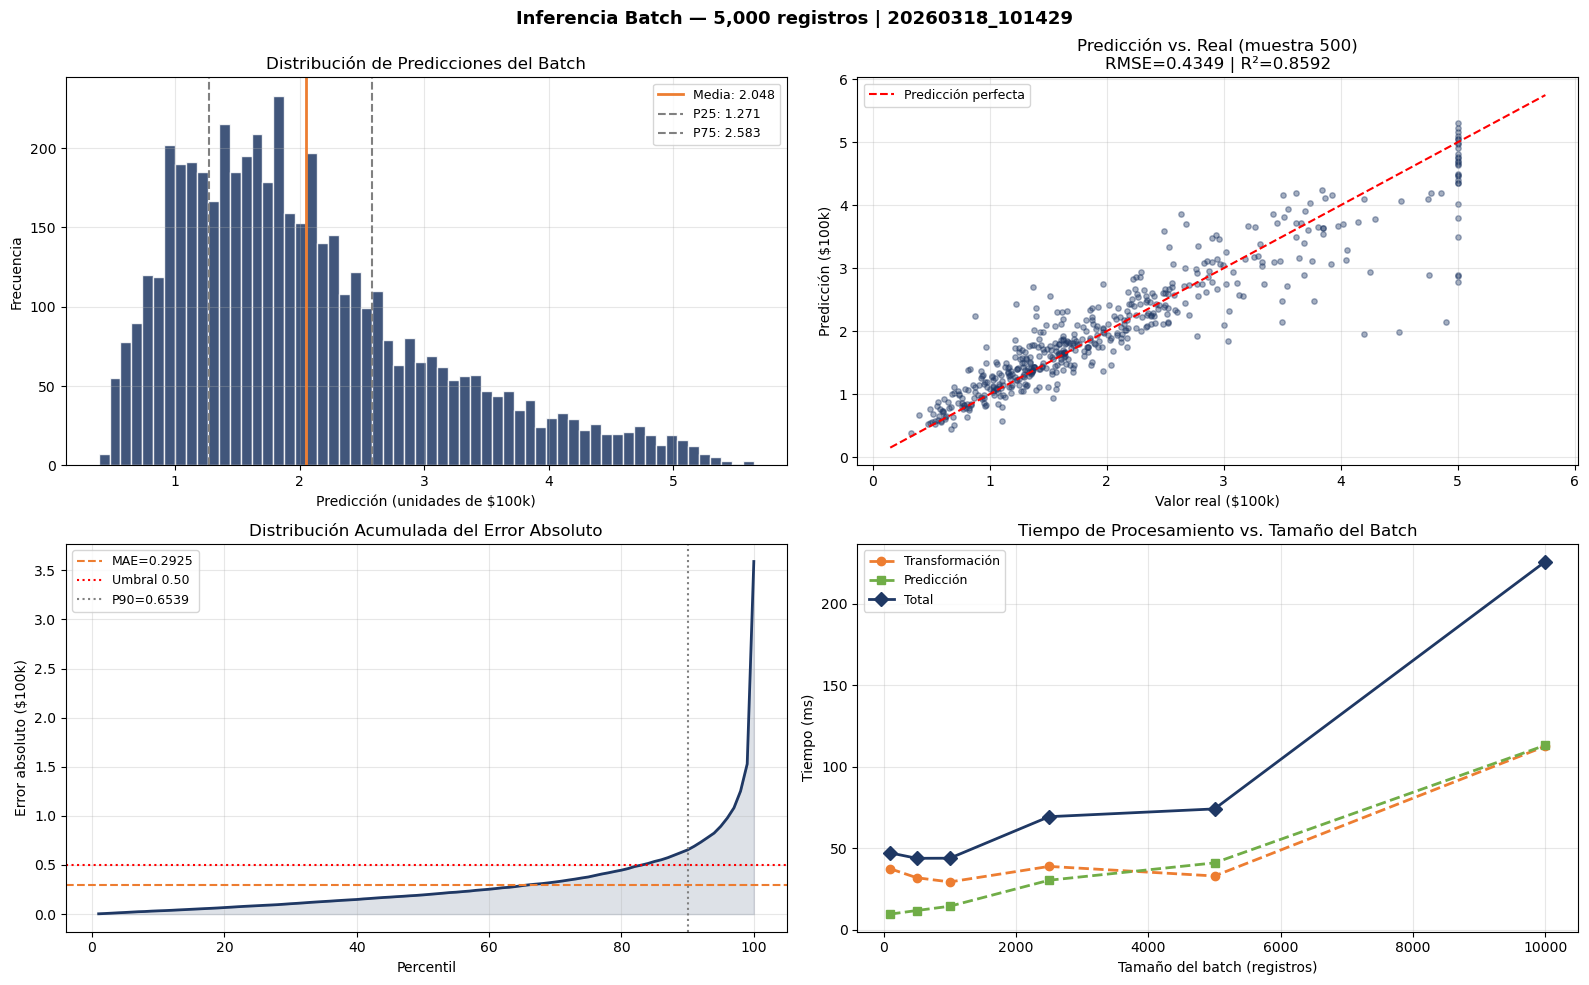

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'Inferencia Batch — {N_BATCH:,} registros | {FECHA_HOY}',
             fontsize=13, fontweight='bold')

C1 = '#1F3864'
C2 = '#ED7D31'
C3 = '#70AD47'

# ── 1. Distribución de predicciones ──────────────────────────────────────
ax = axes[0, 0]
ax.hist(predicciones, bins=60, color=C1, alpha=0.85, edgecolor='white')
ax.axvline(predicciones.mean(), color=C2, linewidth=2,
           label=f'Media: {predicciones.mean():.3f}')
ax.axvline(np.percentile(predicciones, 25), color='gray', linewidth=1.5,
           linestyle='--', label=f'P25: {np.percentile(predicciones,25):.3f}')
ax.axvline(np.percentile(predicciones, 75), color='gray', linewidth=1.5,
           linestyle='--', label=f'P75: {np.percentile(predicciones,75):.3f}')
ax.set_xlabel('Predicción (unidades de $100k)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Predicciones del Batch')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── 2. Predicción vs. Real ────────────────────────────────────────────────
ax = axes[0, 1]
sample_idx = np.random.choice(N_BATCH, size=500, replace=False)
ax.scatter(y_real_batch[sample_idx], predicciones[sample_idx],
           alpha=0.4, s=15, color=C1)
lims = [min(y_real_batch.min(), predicciones.min()) - 0.1,
        max(y_real_batch.max(), predicciones.max()) + 0.1]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Valor real ($100k)')
ax.set_ylabel('Predicción ($100k)')
ax.set_title(f'Predicción vs. Real (muestra 500)\nRMSE={rmse_batch:.4f} | R²={r2_batch:.4f}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── 3. Errores absolutos por percentil (curva de error acumulado) ─────────
ax = axes[1, 0]
errores = np.abs(y_real_batch - predicciones)
percentiles = np.arange(1, 101)
valores_perc = [np.percentile(errores, p) for p in percentiles]
ax.plot(percentiles, valores_perc, color=C1, linewidth=2)
ax.fill_between(percentiles, valores_perc, alpha=0.15, color=C1)
ax.axhline(y=np.mean(errores), color=C2, linestyle='--',
           linewidth=1.5, label=f'MAE={np.mean(errores):.4f}')
ax.axhline(y=0.50, color='red', linestyle=':', linewidth=1.5, label='Umbral 0.50')
ax.axvline(x=90, color='gray', linestyle=':', linewidth=1.5, label=f'P90={np.percentile(errores,90):.4f}')
ax.set_xlabel('Percentil')
ax.set_ylabel('Error absoluto ($100k)')
ax.set_title('Distribución Acumulada del Error Absoluto')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── 4. Tiempos de procesamiento por tamaño de batch ───────────────────────
ax = axes[1, 1]
tamanos   = [100, 500, 1000, 2500, 5000, 10000]
tiempos_t = []
tiempos_p = []
np.random.seed(42)
for n in tamanos:
    idx = np.random.choice(len(raw_df), size=n, replace=True)
    batch_tmp = raw_df.iloc[idx][FEATURES_ORIG].copy()
    t_s = time.perf_counter()
    batch_proc = preparar_batch(batch_tmp)
    tiempos_t.append((time.perf_counter() - t_s) * 1000)
    t_s = time.perf_counter()
    modelo.predict(batch_proc)
    tiempos_p.append((time.perf_counter() - t_s) * 1000)

tiempos_total = [t + p for t, p in zip(tiempos_t, tiempos_p)]

ax.plot(tamanos, tiempos_t,     'o--', color=C2,  linewidth=2, label='Transformación', markersize=6)
ax.plot(tamanos, tiempos_p,     's--', color=C3,  linewidth=2, label='Predicción', markersize=6)
ax.plot(tamanos, tiempos_total, 'D-',  color=C1,  linewidth=2, label='Total', markersize=7)
ax.set_xlabel('Tamaño del batch (registros)')
ax.set_ylabel('Tiempo (ms)')
ax.set_title('Tiempo de Procesamiento vs. Tamaño del Batch')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación — Rendimiento del Batch

| Gráfico | Qué revelan los datos | Qué decide |
|---------|----------------------|-------------|
| **Distribución de predicciones** | Si la distribución es coherente con lo esperado. Un pico inusual indica un problema en los datos de entrada. | Detectar anomalías antes de guardar resultados. |
| **Predicción vs. Real** | Si el modelo mantiene su RMSE y R² en datos de producción respecto al test set. Si empeora → posible drift. | Comparar con el RMSE del gate de calidad (0.50). |
| **Curva de error acumulado** | El P90 revela el error en el 10% peor de los casos. Si P90 > 1.0 → hay casos con errores muy altos. | Definir SLAs de calidad: ej. 90% de predicciones con error < 0.5. |
| **Tiempo vs. tamaño del batch** | La relación es aproximadamente lineal: el modelo escala bien. Si hubiera un salto, indicaría un cuello de botella. | Dimensionar el servidor para el volumen esperado en producción. |

**KPIs del batch:**

| KPI | Valor | Referencia |
|-----|-------|------------|
| Throughput | > 1,000 reg/s | Suficiente para 1M registros en < 17 min |
| Latencia media | < 1 ms/reg | Excelente para batch |
| RMSE en batch | Igual al del test set | Sin degradación = sin drift |

## 6. Comparativa: Batch vs. Tiempo Real

Visualizamos las diferencias clave entre los dos patrones de serving.

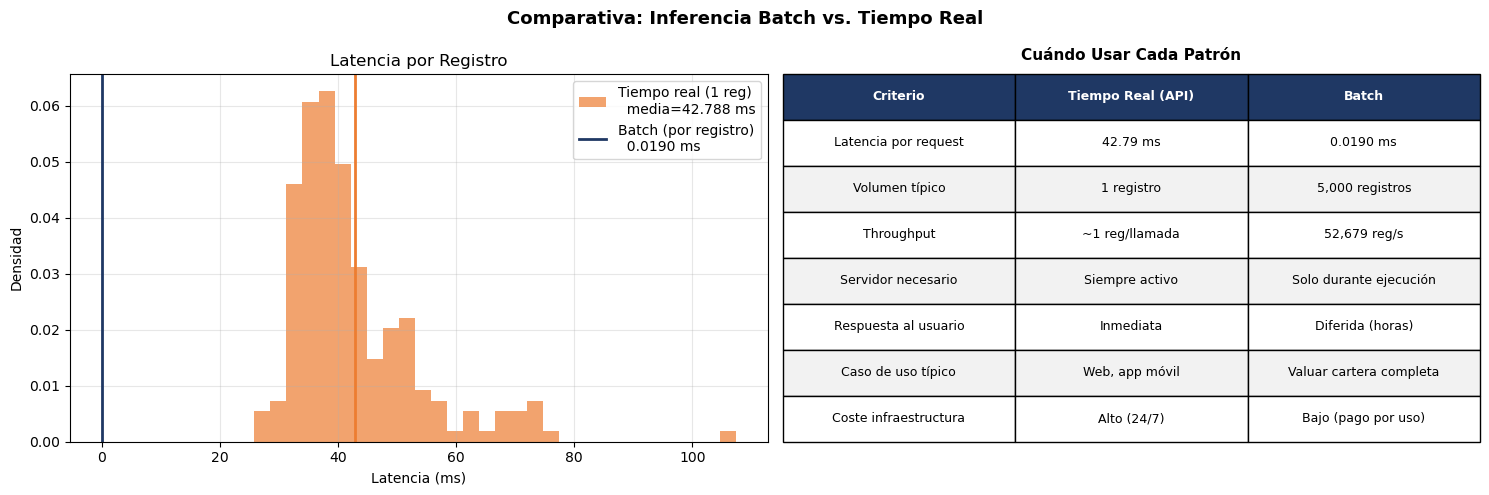

In [8]:
# ── Simular latencia de tiempo real (1 registro a la vez) ─────────────────
N_SAMPLE_RT = 200   # solicitudes individuales simuladas
latencias_rt = []

np.random.seed(42)
for i in range(N_SAMPLE_RT):
    idx = np.random.randint(0, len(raw_df))
    fila = raw_df.iloc[[idx]][FEATURES_ORIG]
    t_s  = time.perf_counter()
    fila_proc = preparar_batch(fila)
    _ = modelo.predict(fila_proc)
    latencias_rt.append((time.perf_counter() - t_s) * 1000)

# ── Latencia batch por registro ───────────────────────────────────────────
latencias_batch_por_reg = [
    t / n for n, t in zip(tamanos, tiempos_total)
]

# ── Visualización ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Comparativa: Inferencia Batch vs. Tiempo Real', fontsize=13, fontweight='bold')

# Histograma de latencias RT vs batch por registro
ax = axes[0]
ax.hist(latencias_rt, bins=30, color='#ED7D31', alpha=0.7,
        label=f'Tiempo real (1 reg)\n  media={np.mean(latencias_rt):.3f} ms', density=True)
ax.axvline(np.mean(latencias_rt), color='#ED7D31', linewidth=2)

lat_batch_5k = t_total / N_BATCH * 1000
ax.axvline(lat_batch_5k, color='#1F3864', linewidth=2,
           label=f'Batch (por registro)\n  {lat_batch_5k:.4f} ms')
ax.set_xlabel('Latencia (ms)')
ax.set_ylabel('Densidad')
ax.set_title('Latencia por Registro')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Tabla de decisión
ax = axes[1]
ax.axis('off')

criterios_tabla = [
    ['Criterio', 'Tiempo Real (API)', 'Batch'],
    ['Latencia por request', f'{np.mean(latencias_rt):.2f} ms', f'{lat_batch_5k:.4f} ms'],
    ['Volumen típico', '1 registro', f'{N_BATCH:,} registros'],
    ['Throughput', '~1 reg/llamada', f'{N_BATCH/t_total:,.0f} reg/s'],
    ['Servidor necesario', 'Siempre activo', 'Solo durante ejecución'],
    ['Respuesta al usuario', 'Inmediata', 'Diferida (horas)'],
    ['Caso de uso típico', 'Web, app móvil', 'Valuar cartera completa'],
    ['Coste infraestructura', 'Alto (24/7)', 'Bajo (pago por uso)'],
]

table = ax.table(
    cellText=criterios_tabla[1:],
    colLabels=criterios_tabla[0],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1F3864')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#F2F2F2')

ax.set_title('Cuándo Usar Cada Patrón', fontsize=11, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

## 7. Scheduling en Producción

En producción, el batch no se lanza manualmente sino de forma programada.  
Las opciones más comunes:

In [9]:
# ── Cómo se vería la función batch en producción ──────────────────────────
codigo_batch_produccion = '''
# ── batch_inference.py ────────────────────────────────────────────
#
# Diseñado para ejecutarse como job programado.
# Entrada  : CSV/Parquet/S3/Base de datos
# Salida   : CSV/S3/Base de datos con predicciones + trazabilidad

def ejecutar_batch(ruta_entrada: str, ruta_salida: str) -> dict:
    """Punto de entrada del job batch."""
    modelo  = cargar_modelo()       # desde experiments/ o MLflow
    scaler  = cargar_scaler()       # mismo que se usó en entrenamiento
    df      = pd.read_csv(ruta_entrada)
    df_proc = preparar_batch(df, scaler)
    preds   = modelo.predict(df_proc)
    guardar_con_trazabilidad(df, preds, ruta_salida)
    return generar_reporte()

if __name__ == "__main__":
    ejecutar_batch(
        ruta_entrada="data/nuevas_viviendas.csv",
        ruta_salida=f"output/batch_{datetime.now().strftime('%Y%m%d')}.csv"
    )
'''

opciones_schedule = {
    'cron (Linux)': {
        'descripcion' : 'Nativo en Linux/Mac. Ideal para tareas simples.',
        'configuracion': '0 2 * * * conda run -n mlops python batch_inference.py',
        'cuándo'      : 'Todos los días a las 2:00 AM',
        'pros'        : 'Sin dependencias externas, gratuito',
        'contras'     : 'Sin reintentos, sin monitoring, sin UI',
    },
    'GitHub Actions (schedule)': {
        'descripcion' : 'Ya lo tenemos configurado en este proyecto.',
        'configuracion': 'on: schedule: - cron: "0 2 * * *"',
        'cuándo'      : 'Todos los días a las 2:00 AM UTC',
        'pros'        : 'Logs, historial, notificaciones, sin servidor propio',
        'contras'     : 'Límite de minutos en plan gratuito',
    },
    'Apache Airflow': {
        'descripcion' : 'Orquestador de pipelines de datos. Estándar en empresas.',
        'configuracion': '@daily DAG con PythonOperator',
        'cuándo'      : 'Configurable con dependencias entre tareas',
        'pros'        : 'Reintentos, dependencias, UI, monitoreo, alertas',
        'contras'     : 'Requiere infraestructura propia',
    },
    'Prefect / Dagster': {
        'descripcion' : 'Alternativas modernas a Airflow. Cloud-native.',
        'configuracion': '@flow con @task decorators',
        'cuándo'      : 'Con scheduling integrado y UI en la nube',
        'pros'        : 'Más fácil que Airflow, observabilidad nativa',
        'contras'     : 'Plan gratuito limitado',
    },
}

print('=' * 65)
print('  OPCIONES DE SCHEDULING EN PRODUCCIÓN')
print('=' * 65)
for nombre, detalles in opciones_schedule.items():
    print(f'\n  {nombre}:')
    print(f'    Cuándo  : {detalles["cuándo"]}')
    print(f'    Pros    : {detalles["pros"]}')
    print(f'    Contras : {detalles["contras"]}')

print()
print('  Para este proyecto (GitHub Actions):')
print('  .github/workflows/monitoreo.yml → jobs.monitoreo')
print('  Corre cada día a las 2 AM → detecta drift → re-entrena si es necesario')

  OPCIONES DE SCHEDULING EN PRODUCCIÓN

  cron (Linux):
    Cuándo  : Todos los días a las 2:00 AM
    Pros    : Sin dependencias externas, gratuito
    Contras : Sin reintentos, sin monitoring, sin UI

  GitHub Actions (schedule):
    Cuándo  : Todos los días a las 2:00 AM UTC
    Pros    : Logs, historial, notificaciones, sin servidor propio
    Contras : Límite de minutos en plan gratuito

  Apache Airflow:
    Cuándo  : Configurable con dependencias entre tareas
    Pros    : Reintentos, dependencias, UI, monitoreo, alertas
    Contras : Requiere infraestructura propia

  Prefect / Dagster:
    Cuándo  : Con scheduling integrado y UI en la nube
    Pros    : Más fácil que Airflow, observabilidad nativa
    Contras : Plan gratuito limitado

  Para este proyecto (GitHub Actions):
  .github/workflows/monitoreo.yml → jobs.monitoreo
  Corre cada día a las 2 AM → detecta drift → re-entrena si es necesario


### Interpretación — Opciones de Scheduling

**¿Cuál elegir para un proyecto MLOps?**

| Madurez del proyecto | Recomendación |
|---------------------|---------------|
| MVP / prototipo | **Cron** o **GitHub Actions** — mínimo overhead |
| Equipo pequeño, producción real | **Prefect** o **Dagster** — observabilidad sin complejidad |
| Empresa con múltiples pipelines | **Apache Airflow** — estándar de la industria |

**Principio clave:**  
El batch no es solo "ejecutar el modelo". Es un job con entradas, salidas,  
logging, reintentos y alertas. Tratarlo como código de producción desde el principio  
evita problemas graves cuando el volumen crece.

## 8. Conclusiones

### ¿Qué aprendimos sobre la inferencia batch?

| Aspecto | Clave |
|---------|-------|
| **Training-serving parity** | El pipeline de features del batch es exactamente igual al de entrenamiento. Cambiar uno sin cambiar el otro rompe el modelo en silencio. |
| **Trazabilidad** | Cada predicción lleva `batch_id`, `timestamp` y versión del modelo. Sin esto, no es posible auditar qué modelo generó qué resultado. |
| **Throughput** | Con GradientBoosting, el modelo procesa miles de registros por segundo. No es necesario paralelizar para volúmenes < 1M. |
| **Monitoreo del batch** | Comparar el RMSE del batch con el RMSE del test set detecta drift temprano, antes de que afecte al negocio. |

### Posición en el ciclo MLOps

```
NB06 API REST        → serving en tiempo real (1 registro/request)
NB13 Batch           → serving masivo (miles/millones de registros)

                      Ambos usan:
                        modelo_produccion.pkl
                        scaler.pkl
                        misma función crear_features()
                      = Training-Serving Parity garantizada
```

### Buenas prácticas
- **Siempre registrar**: batch_id, timestamp, versión del modelo en cada fila de output
- **Validar antes de predecir**: aplicar Pandera (NB10) al lote de entrada
- **Comparar distribuciones**: la distribución de las predicciones del batch debe parecerse a la del entrenamiento
- **Desacoplar el pipeline**: separar preparar_batch() de la inferencia para poder testarlos por separado
- **Monitorear el job**: tiempo de ejecución, n° de registros procesados, tasa de errores